Este notebook ejecuta el benchmark completo de modelos de detección de anomalías sobre el dataset de segmentos AIS.

Incluye:
- métodos clásicos no supervisados,
- variantes de configuración,
- un autoencoder,
- y una red neuronal simple como referencia adicional.

Los resultados se guardan en disco para su posterior análisis en el notebook principal de selección de modelo.

## Imports

In [ ]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

## Datos

Carpeta de resultados

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/TFG/"
data_path = base_path + "data_processed/"
results_path = base_path + "results/benchmark/"

os.makedirs(results_path, exist_ok=True)

train_df = pd.read_csv(data_path + "train_clean.csv")
test_df = pd.read_csv(data_path + "test_augmented.csv")

import joblib
feature_cols = joblib.load(data_path + "feature_cols.pkl")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (1228043, 37)
Test: (312778, 39)


In [ ]:
models_path = base_path + "models/"
os.makedirs(models_path, exist_ok=True)

Cargamos los datasets y las listas de features

In [ ]:
train_df = pd.read_csv(data_path + "train_clean.csv")
test_df = pd.read_csv(data_path + "test_augmented.csv")

feature_cols = joblib.load(data_path + "feature_cols.pkl")
base_features = joblib.load(data_path + "base_features.pkl")
derived_features = joblib.load(data_path + "derived_features.pkl")
domain_features = joblib.load(data_path + "domain_features.pkl")

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Total features:", len(feature_cols))

Train: (1228043, 37)
Test: (312778, 39)
Total features: 27


Definimos feature sets

In [ ]:
features_full = feature_cols

features_reduced = [
    "speed_mean",
    "delta_course_mean",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap",
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag"
]

feature_sets = {
    "full": features_full,
    "reduced": features_reduced,
    "base_only": base_features,
    "base_derived": list(dict.fromkeys(base_features + derived_features)),
    "domain_only": domain_features
}

for name, fs in feature_sets.items():
    print(name, len(fs))

full 27
reduced 9
base_only 13
base_derived 21
domain_only 6


## Split validation/holdout

In [ ]:
validation_df, holdout_df = train_test_split(
    test_df,
    test_size=0.5,
    random_state=42,
    stratify=test_df["anomaly_type"]
)

print("Validation:", validation_df.shape)
print("Holdout:", holdout_df.shape)
print("\nValidation anomaly types:")
print(validation_df["anomaly_type"].value_counts())
print("\nHoldout anomaly types:")
print(holdout_df["anomaly_type"].value_counts())

Validation: (156389, 39)
Holdout: (156389, 39)

Validation anomaly types:
anomaly_type
normal             147539
loitering_like       1475
close_approach       1475
ais_gap_anomaly      1475
zigzag_anomaly       1475
speed_anomaly        1475
route_deviation      1475
Name: count, dtype: int64

Holdout anomaly types:
anomaly_type
normal             147539
speed_anomaly        1475
close_approach       1475
ais_gap_anomaly      1475
route_deviation      1475
zigzag_anomaly       1475
loitering_like       1475
Name: count, dtype: int64


## Funciones auxiliares

In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

def prepare_scaled_data(train_df, eval_df, features):
    X_train = train_df[features].copy()
    X_eval = eval_df[features].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    return X_train, X_eval, X_train_scaled, X_eval_scaled, scaler

def save_result(results_list, model_name, feature_set_name, config_dict, metrics, elapsed):
    row = {
        "model": model_name,
        "feature_set": feature_set_name,
        "n_features": len(feature_sets[feature_set_name]),
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "time_sec": elapsed,
        "config_json": json.dumps(config_dict)
    }
    row.update(config_dict)
    results_list.append(row)

## Evaluador Isolation Forest

In [ ]:
def run_iforest(train_df, eval_df, features, contamination=0.06, n_estimators=100, random_state=42):
    _, _, X_train_scaled, X_eval_scaled, _ = prepare_scaled_data(train_df, eval_df, features)

    start = time.time()

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train_scaled)
    y_pred = (model.predict(X_eval_scaled) == -1).astype(int)

    elapsed = time.time() - start
    metrics = compute_metrics(eval_df["is_synthetic"], y_pred)

    return metrics, elapsed, y_pred

## Evaluador LOF

In [ ]:
def run_lof(train_df, eval_df, features, contamination=0.06, n_neighbors=20):
    _, _, X_train_scaled, X_eval_scaled, _ = prepare_scaled_data(train_df, eval_df, features)

    start = time.time()

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=True
    )
    model.fit(X_train_scaled)
    y_pred = (model.predict(X_eval_scaled) == -1).astype(int)

    elapsed = time.time() - start
    metrics = compute_metrics(eval_df["is_synthetic"], y_pred)

    return metrics, elapsed, y_pred

## Evaluador OCSVM

In [ ]:
def run_ocsvm(train_df, eval_df, features, nu=0.05, kernel="rbf", gamma="scale"):
    _, _, X_train_scaled, X_eval_scaled, _ = prepare_scaled_data(train_df, eval_df, features)

    start = time.time()

    model = OneClassSVM(
        nu=nu,
        kernel=kernel,
        gamma=gamma
    )
    model.fit(X_train_scaled)
    y_pred = (model.predict(X_eval_scaled) == -1).astype(int)

    elapsed = time.time() - start
    metrics = compute_metrics(eval_df["is_synthetic"], y_pred)

    return metrics, elapsed, y_pred

## Evaluador Autoencoder

In [ ]:
def run_autoencoder(train_df, eval_df, features, epochs=12, batch_size=256, threshold_percentile=95, random_state=42):
    tf.keras.utils.set_random_seed(random_state)

    _, _, X_train_scaled, X_eval_scaled, _ = prepare_scaled_data(train_df, eval_df, features)

    input_dim = X_train_scaled.shape[1]
    encoding_dim = max(4, input_dim // 2)

    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(encoding_dim, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)

    autoencoder = keras.Model(inputs, outputs)
    autoencoder.compile(optimizer="adam", loss="mse")

    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    start = time.time()

    autoencoder.fit(
        X_train_scaled, X_train_scaled,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    recon = autoencoder.predict(X_eval_scaled, verbose=0)
    errors = np.mean((X_eval_scaled - recon) ** 2, axis=1)

    threshold = np.percentile(errors, threshold_percentile)
    y_pred = (errors > threshold).astype(int)

    elapsed = time.time() - start
    metrics = compute_metrics(eval_df["is_synthetic"], y_pred)

    return metrics, elapsed, y_pred

## Evaluador MLP supervidada

In [ ]:
def run_mlp_supervised(eval_df, features, epochs=12, batch_size=256, threshold=0.5, random_state=42):
    tf.keras.utils.set_random_seed(random_state)

    mlp_train_df, mlp_val_df = train_test_split(
        eval_df,
        test_size=0.3,
        random_state=random_state,
        stratify=eval_df["is_synthetic"]
    )

    X_train = mlp_train_df[features].copy()
    y_train = mlp_train_df["is_synthetic"].copy()

    X_val = mlp_val_df[features].copy()
    y_val = mlp_val_df["is_synthetic"].copy()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    start = time.time()

    model.fit(
        X_train_scaled, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    y_prob = model.predict(X_val_scaled, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    elapsed = time.time() - start
    metrics = compute_metrics(y_val, y_pred)

    return metrics, elapsed, y_pred

## Configuración del benchmark

In [ ]:
benchmark_results = []

benchmark_configs = [
    {"model": "IF", "feature_set": "full", "contamination": 0.06, "n_estimators": 100},
    {"model": "IF", "feature_set": "reduced", "contamination": 0.06, "n_estimators": 100},
    {"model": "IF", "feature_set": "base_only", "contamination": 0.06, "n_estimators": 100},

    {"model": "LOF", "feature_set": "reduced", "contamination": 0.06, "n_neighbors": 20},
    {"model": "LOF", "feature_set": "base_only", "contamination": 0.06, "n_neighbors": 20},

    {"model": "OCSVM", "feature_set": "reduced", "nu": 0.05, "kernel": "rbf", "gamma": "scale"},

    {"model": "AE", "feature_set": "reduced", "epochs": 12, "batch_size": 256, "threshold_percentile": 95},
    {"model": "AE", "feature_set": "base_only", "epochs": 12, "batch_size": 256, "threshold_percentile": 95},

    {"model": "MLP", "feature_set": "reduced", "epochs": 12, "batch_size": 256, "threshold": 0.5}
]

print("Número de configuraciones:", len(benchmark_configs))

Número de configuraciones: 9


In [ ]:
all_val_predictions = {}

for i, cfg in enumerate(benchmark_configs, 1):
    model_name = cfg["model"]
    feature_set_name = cfg["feature_set"]
    features = feature_sets[feature_set_name]

    print(f"[{i}/{len(benchmark_configs)}] Ejecutando {model_name} - {feature_set_name}...")

    if model_name == "IF":
        metrics, elapsed, y_pred = run_iforest(
            train_df=train_df,
            eval_df=validation_df,
            features=features,
            contamination=cfg["contamination"],
            n_estimators=cfg["n_estimators"]
        )

    elif model_name == "LOF":
        metrics, elapsed, y_pred = run_lof(
            train_df=train_df,
            eval_df=validation_df,
            features=features,
            contamination=cfg["contamination"],
            n_neighbors=cfg["n_neighbors"]
        )

    elif model_name == "OCSVM":
        metrics, elapsed, y_pred = run_ocsvm(
            train_df=train_df,
            eval_df=validation_df,
            features=features,
            nu=cfg["nu"],
            kernel=cfg["kernel"],
            gamma=cfg["gamma"]
        )

    elif model_name == "AE":
        metrics, elapsed, y_pred = run_autoencoder(
            train_df=train_df,
            eval_df=validation_df,
            features=features,
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            threshold_percentile=cfg["threshold_percentile"]
        )

    elif model_name == "MLP":
        metrics, elapsed, y_pred = run_mlp_supervised(
            eval_df=validation_df,
            features=features,
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            threshold=cfg["threshold"]
        )

    save_result(
        benchmark_results,
        model_name=model_name,
        feature_set_name=feature_set_name,
        config_dict=cfg,
        metrics=metrics,
        elapsed=elapsed
    )

    key = f"{model_name}_{feature_set_name}_{i}"
    all_val_predictions[key] = y_pred

    print(f"F1={metrics['f1']:.4f} | Precision={metrics['precision']:.4f} | Recall={metrics['recall']:.4f} | Time={elapsed:.2f}s")
    print("-" * 70)

[1/9] Ejecutando IF - full...
F1=0.0770 | Precision=0.0755 | Recall=0.0786 | Time=9.30s
----------------------------------------------------------------------
[2/9] Ejecutando IF - reduced...
F1=0.1133 | Precision=0.1096 | Recall=0.1173 | Time=8.70s
----------------------------------------------------------------------
[3/9] Ejecutando IF - base_only...
F1=0.0825 | Precision=0.0808 | Recall=0.0844 | Time=8.29s
----------------------------------------------------------------------
[4/9] Ejecutando LOF - reduced...
F1=0.4527 | Precision=0.3709 | Recall=0.5809 | Time=394.06s
----------------------------------------------------------------------
[5/9] Ejecutando LOF - base_only...
F1=0.4187 | Precision=0.3432 | Recall=0.5369 | Time=1581.60s
----------------------------------------------------------------------
[6/9] Ejecutando OCSVM - reduced...
F1=0.4498 | Precision=0.3928 | Recall=0.5262 | Time=17893.33s
----------------------------------------------------------------------
[7/9] Ejecuta

## Resultados

In [ ]:
benchmark_results_df = pd.DataFrame(benchmark_results).sort_values("f1", ascending=False).reset_index(drop=True)
benchmark_results_df

,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
0,MLP,reduced,9,0.993232,0.442185,0.611936,20.801086,"{""model"": ""MLP"", ""feature_set"": ""reduced"", ""ep...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,NaN,0.5
1,AE,reduced,9,0.525703,0.464520,0.493221,164.613829,"{""model"": ""AE"", ""feature_set"": ""reduced"", ""epo...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
2,LOF,reduced,9,0.370870,0.580904,0.452712,394.063941,"{""model"": ""LOF"", ""feature_set"": ""reduced"", ""co...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OCSVM,reduced,9,0.392764,0.526215,0.449800,17893.325712,"{""model"": ""OCSVM"", ""feature_set"": ""reduced"", ""...",NaN,NaN,NaN,0.05,rbf,scale,NaN,NaN,NaN,NaN
4,LOF,base_only,13,0.343154,0.536949,0.418715,1581.603543,"{""model"": ""LOF"", ""feature_set"": ""base_only"", ""...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AE,base_only,13,0.335678,0.296610,0.314937,169.916305,"{""model"": ""AE"", ""feature_set"": ""base_only"", ""e...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
6,IF,reduced,9,0.109598,0.117288,0.113313,8.704440,"{""model"": ""IF"", ""feature_set"": ""reduced"", ""con...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,IF,base_only,13,0.080757,0.084407,0.082541,8.289271,"{""model"": ""IF"", ""feature_set"": ""base_only"", ""c...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,IF,full,27,0.075464,0.078644,0.077021,9.295924,"{""model"": ""IF"", ""feature_set"": ""full"", ""contam...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


El benchmark muestra que usar un conjunto reducido de variables marítimas mejora claramente la detección de anomalías frente a usar todas las variables. Entre los métodos no supervisados, el Autoencoder con variables reducidas ofrece el mejor equilibrio entre precisión y capacidad de detección, mientras que LOF con variables reducidas detecta más anomalías pero comete más falsos positivos. OCSVM logra resultados parecidos a LOF, pero su coste computacional es demasiado alto. Isolation Forest presenta un rendimiento claramente inferior. Aunque el MLP obtiene la mejor F1 global, su naturaleza supervisada hace que sus resultados no sean directamente comparables con los detectores no supervisados del benchmark principal.

La reducción de variables ha sido un acierto.

In [ ]:
benchmark_results_df.to_csv(results_path + "benchmark_results.csv", index=False)
print("Guardado:", results_path + "benchmark_results.csv")

Guardado: /content/drive/MyDrive/TFG/results/benchmark/benchmark_results.csv


In [ ]:
benchmark_results_df[[
    "model", "feature_set", "precision", "recall", "f1", "time_sec"
]].head(10)

,model,feature_set,precision,recall,f1,time_sec
0,MLP,reduced,0.993232,0.442185,0.611936,20.801086
1,AE,reduced,0.525703,0.464520,0.493221,164.613829
2,LOF,reduced,0.370870,0.580904,0.452712,394.063941
3,OCSVM,reduced,0.392764,0.526215,0.449800,17893.325712
4,LOF,base_only,0.343154,0.536949,0.418715,1581.603543
5,AE,base_only,0.335678,0.296610,0.314937,169.916305
6,IF,reduced,0.109598,0.117288,0.113313,8.704440
7,IF,base_only,0.080757,0.084407,0.082541,8.289271
8,IF,full,0.075464,0.078644,0.077021,9.295924


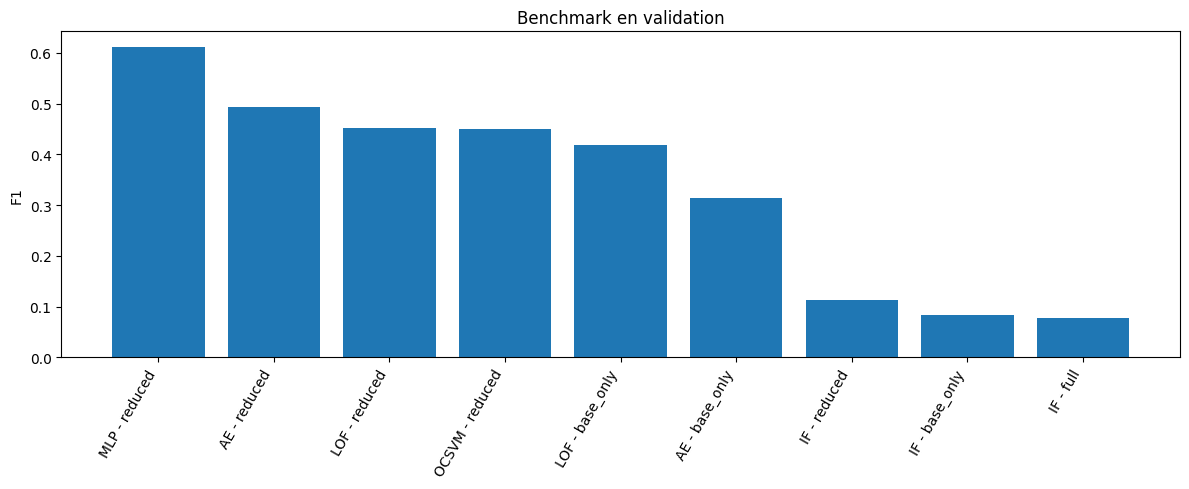

In [ ]:
plot_df = benchmark_results_df.copy()
plot_df["label"] = plot_df["model"] + " - " + plot_df["feature_set"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["f1"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("F1")
plt.title("Benchmark en validation")
plt.tight_layout()
plt.show()

Finalistas:

In [ ]:
finalists_df = benchmark_results_df.head(4).copy()
finalists_df

,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
0,MLP,reduced,9,0.993232,0.442185,0.611936,20.801086,"{""model"": ""MLP"", ""feature_set"": ""reduced"", ""ep...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,NaN,0.5
1,AE,reduced,9,0.525703,0.464520,0.493221,164.613829,"{""model"": ""AE"", ""feature_set"": ""reduced"", ""epo...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
2,LOF,reduced,9,0.370870,0.580904,0.452712,394.063941,"{""model"": ""LOF"", ""feature_set"": ""reduced"", ""co...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OCSVM,reduced,9,0.392764,0.526215,0.449800,17893.325712,"{""model"": ""OCSVM"", ""feature_set"": ""reduced"", ""...",NaN,NaN,NaN,0.05,rbf,scale,NaN,NaN,NaN,NaN


In [ ]:
finalists_df.to_csv(results_path + "benchmark_finalists.csv", index=False)
print("Guardado:", results_path + "benchmark_finalists.csv")

Guardado: /content/drive/MyDrive/TFG/results/benchmark/benchmark_finalists.csv
